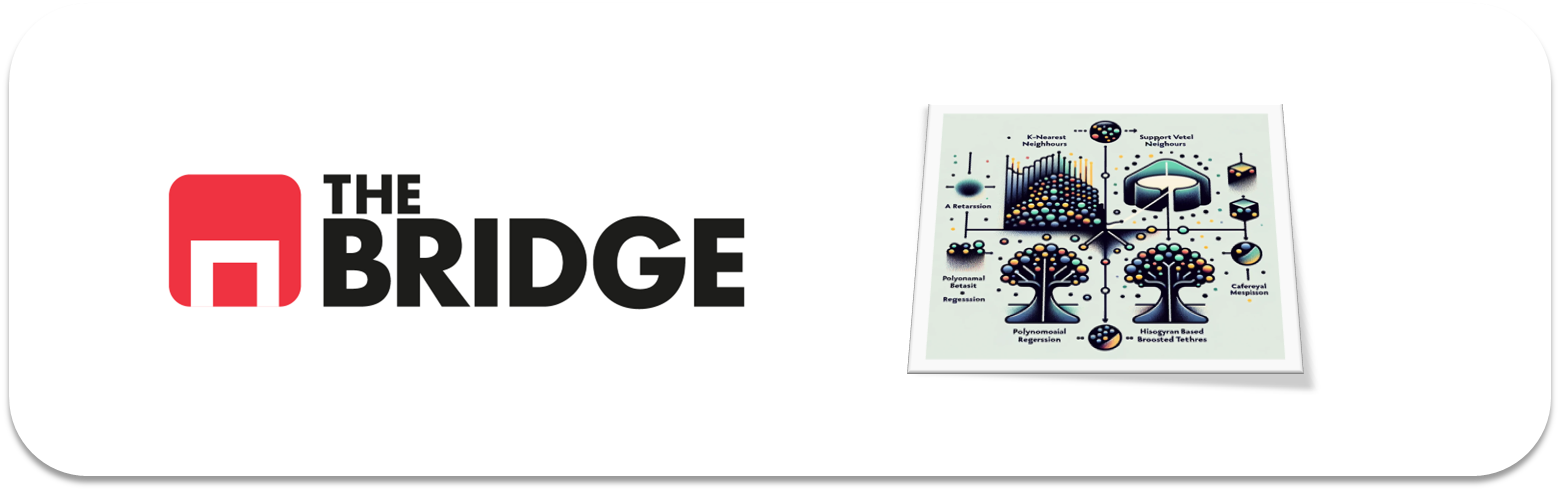

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    mean_absolute_percentage_error,
)

warnings.filterwarnings("ignore")


def buscar_fichero(nombre, directorio_inicio="."):
    """Busca `nombre` en el directorio actual y en todas sus subcarpetas."""
    candidatas = [os.path.join(directorio_inicio, nombre)]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta
    for raiz, _, ficheros in os.walk(directorio_inicio):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)
    return None


ruta_bootcamp = buscar_fichero("bootcampviztools.py")
if ruta_bootcamp is None:
    raise FileNotFoundError("No se ha encontrado 'bootcampviztools.py' junto al notebook.")
sys.path.append(os.path.dirname(os.path.abspath(ruta_bootcamp)))
import bootcampviztools as bt

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
np.random.seed(42)


In [2]:
def plot_predicciones_vs_reales(y_real, y_pred, titulo="Predicción vs. valor real"):
    """Scatter de valores predichos vs reales, con la diagonal y=x de referencia."""
    plt.figure(figsize=(7, 6))
    plt.scatter(y_pred, y_real, alpha=0.4)
    limite_inf = min(min(y_real), min(y_pred))
    limite_sup = max(max(y_real), max(y_pred))
    plt.plot([limite_inf, limite_sup], [limite_inf, limite_sup], color="red", linestyle="--")
    plt.xlabel("Valor predicho")
    plt.ylabel("Valor real")
    plt.title(titulo)
    plt.show()


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [3]:
ruta_csv = buscar_fichero("wines_dataset.csv")
if ruta_csv is None:
    raise FileNotFoundError(
        "No se ha encontrado 'wines_dataset.csv'. Colócalo en alguna subcarpeta (p.ej. "
        "'data/') dentro del directorio de este notebook."
    )

print("Cargando dataset desde:", ruta_csv)
df = pd.read_csv(ruta_csv, sep="|")
df.shape

Cargando dataset desde: .\data\wines_dataset.csv


(6497, 13)

In [4]:
df.head(10)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.210,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.160,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.180,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.260,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.630,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
5,5.7,0.265,0.28,6.90,0.036,46.0,150.0,0.99299,3.36,0.44,10.8,7,white
6,6.6,0.210,0.31,11.40,0.039,46.0,165.0,0.99795,3.41,0.44,9.8,7,white
7,6.7,0.310,0.30,2.10,0.038,18.0,130.0,0.99280,3.36,0.63,10.6,6,white
8,8.9,0.750,0.14,2.50,0.086,9.0,30.0,0.99824,3.34,0.64,10.5,5,red
9,7.5,0.420,0.20,1.40,0.060,15.0,168.0,0.99440,3.06,0.40,9.4,6,white


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [6]:
target_clf = "quality"
target_reg = "alcohol"

df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [7]:
df[target_clf].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

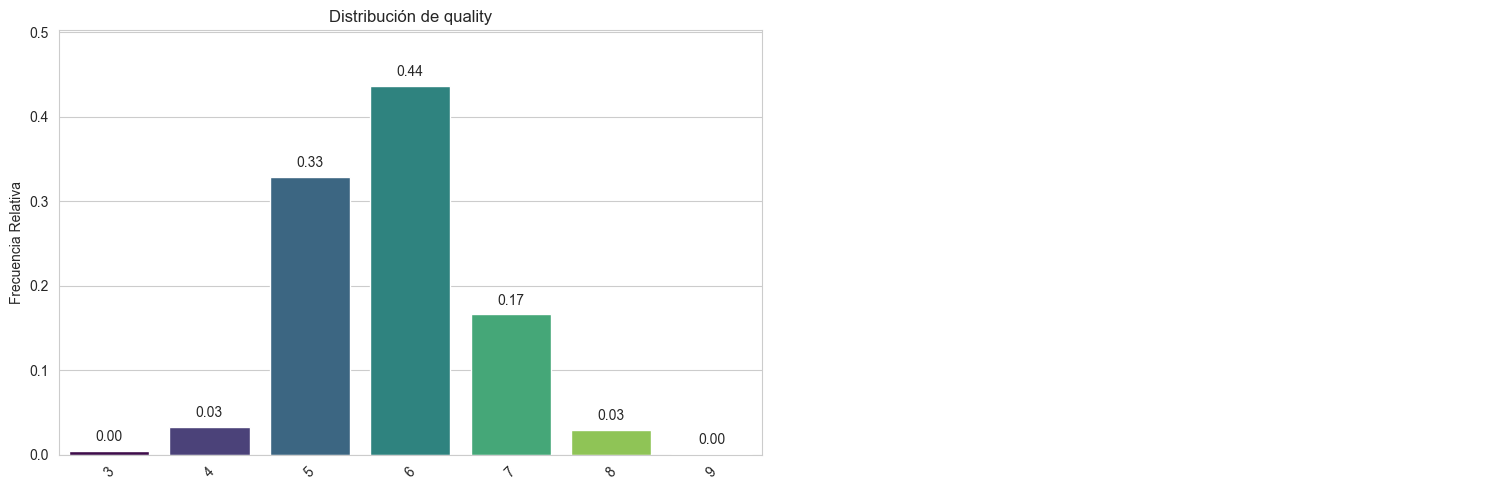

In [8]:
#DISTRIBUCIÓN TARGET CLASIFICACIÓN
bt.pinta_distribucion_categoricas(df, [target_clf], mostrar_valores=True, relativa=True)

Es un problema multiclase muy desbalanceado (la mayoría de vinos puntúan 5, 6 o 7;
las puntuaciones extremas 3, 4, 8 y 9 son minoritarias). Tendremos que abordar ese
desequilibrio de alguna forma.

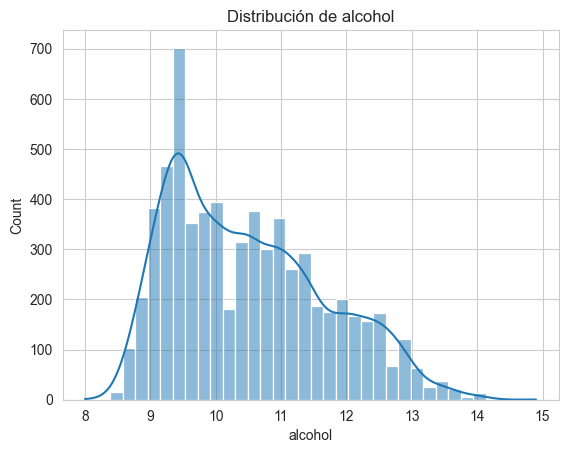

In [9]:
#DISTRIBUCIÓN TARGET REGRESIÓN
sns.histplot(df[target_reg], kde=True)
plt.title("Distribución de alcohol")
plt.show()

La distribución de `alcohol` no es perfectamente normal (algo de asimetría positiva),
pero tampoco es preocupante -- incluso un modelo lineal debería poder capturar buena parte
de la señal.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [10]:
# Split único, compartido entre clasificación y regresión.
# Estratificamos por quality (el target más desbalanceado de los dos) para que
# ambos conjuntos conserven la misma proporción de clases.
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target_clf])

train_set.shape, test_set.shape

((5197, 13), (1300, 13))

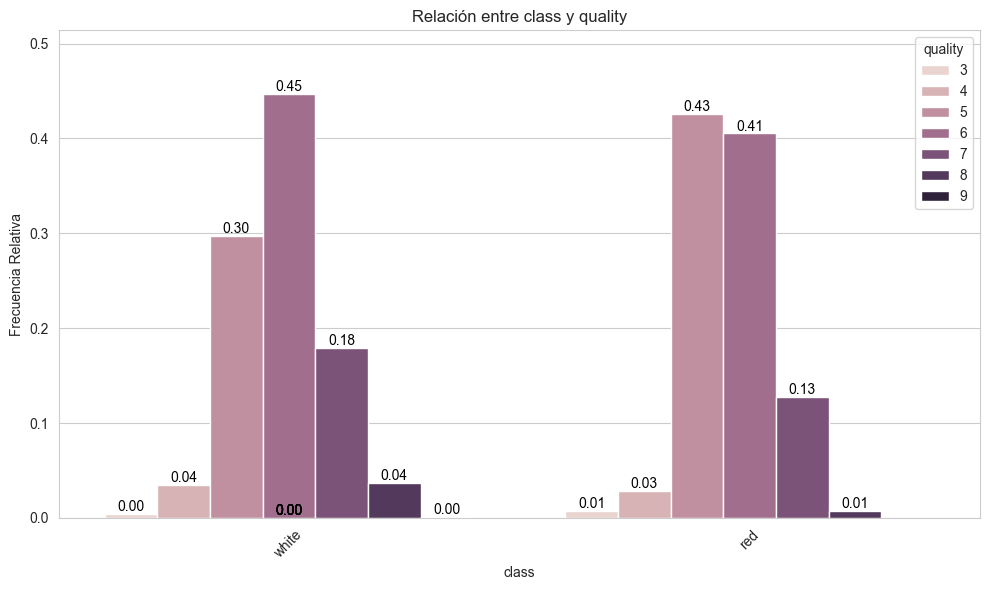

In [11]:
#VARIABLE CATEGÓRICA CLASS
bt.plot_categorical_relationship(train_set, "class", target_clf, show_values=True, relative_freq=True)

In [12]:
features_num = [c for c in train_set.columns if c not in ("class", target_clf)]
len(features_num)

11

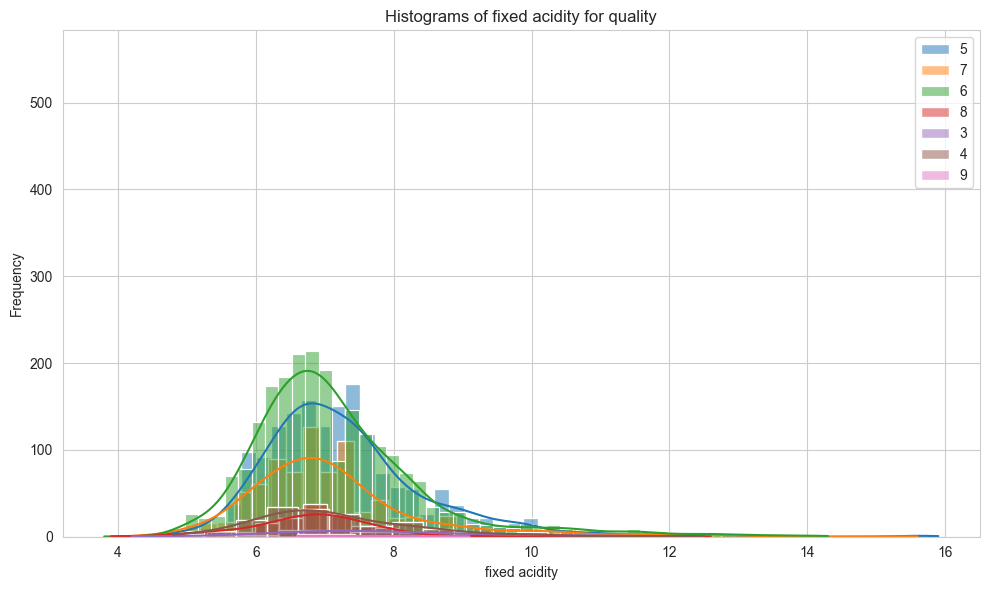

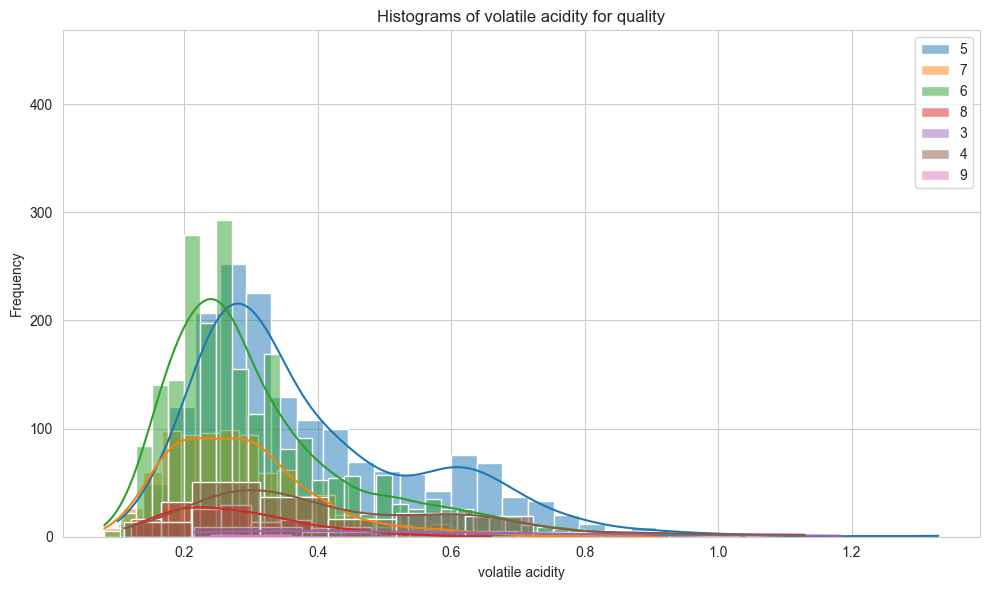

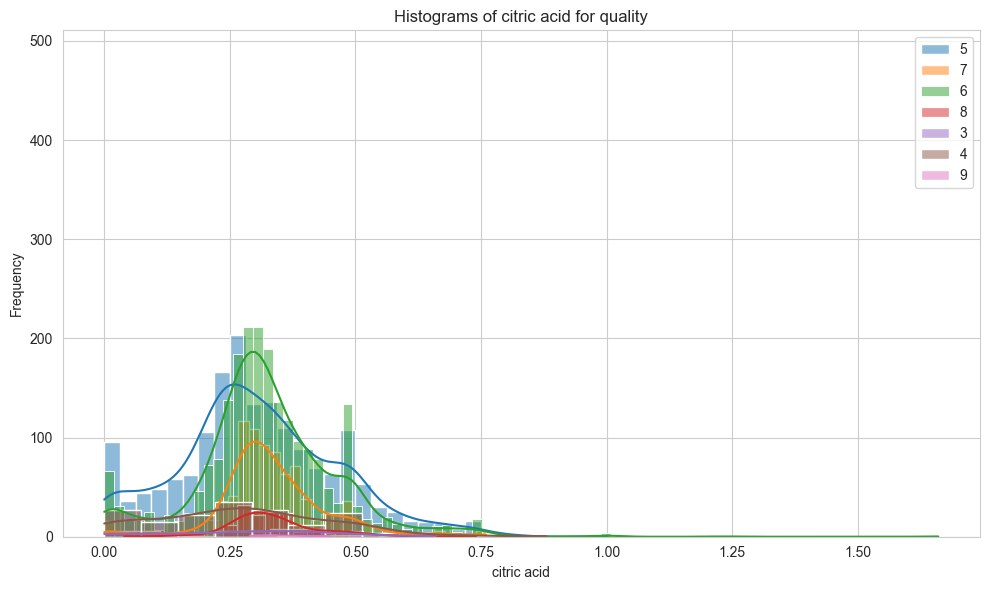

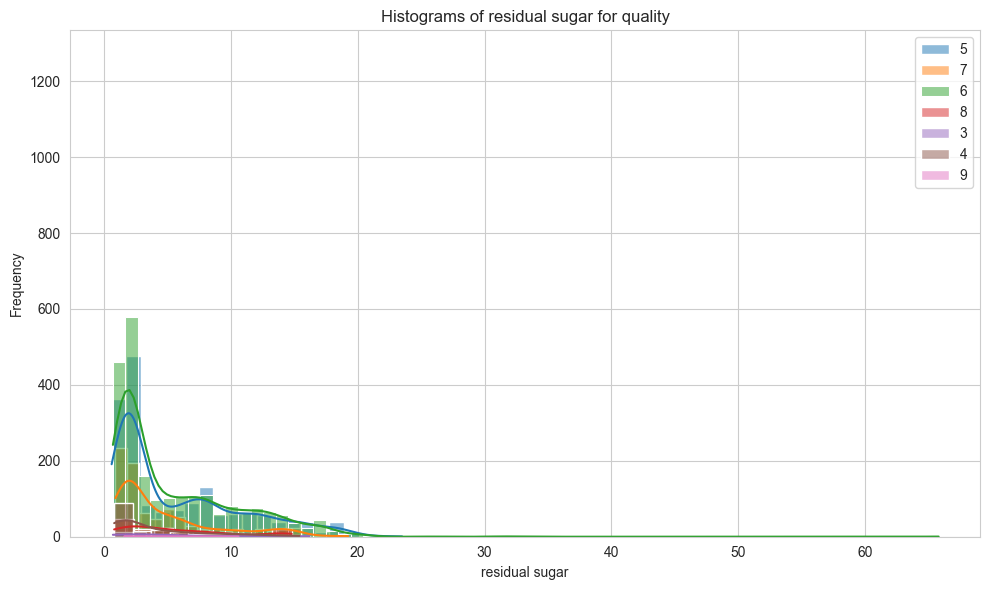

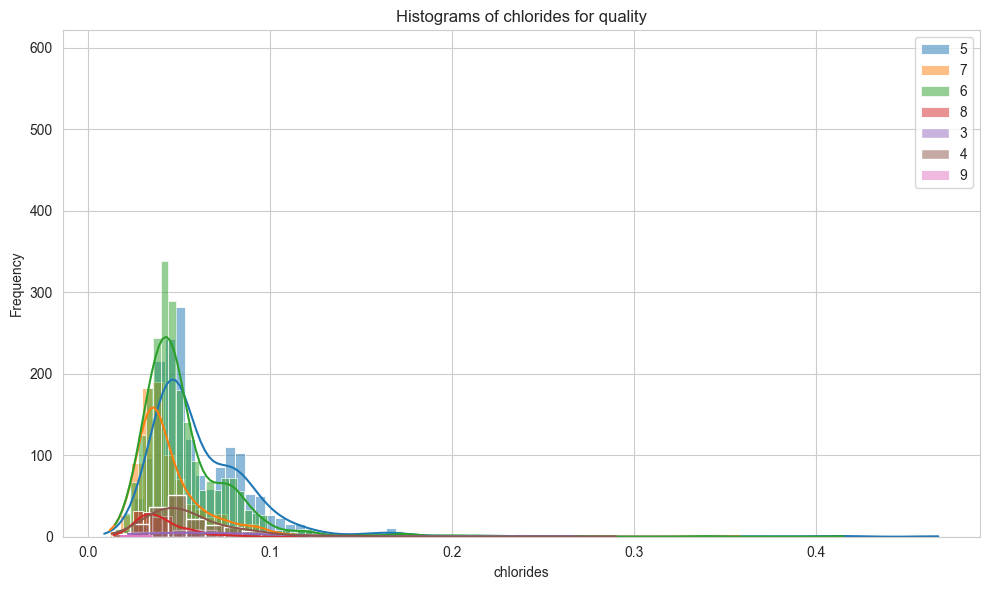

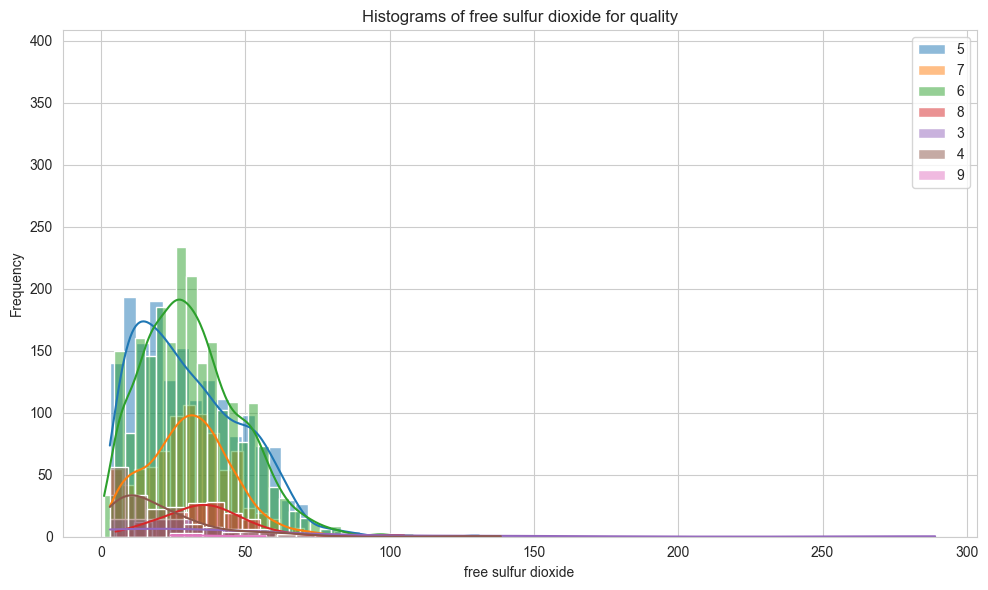

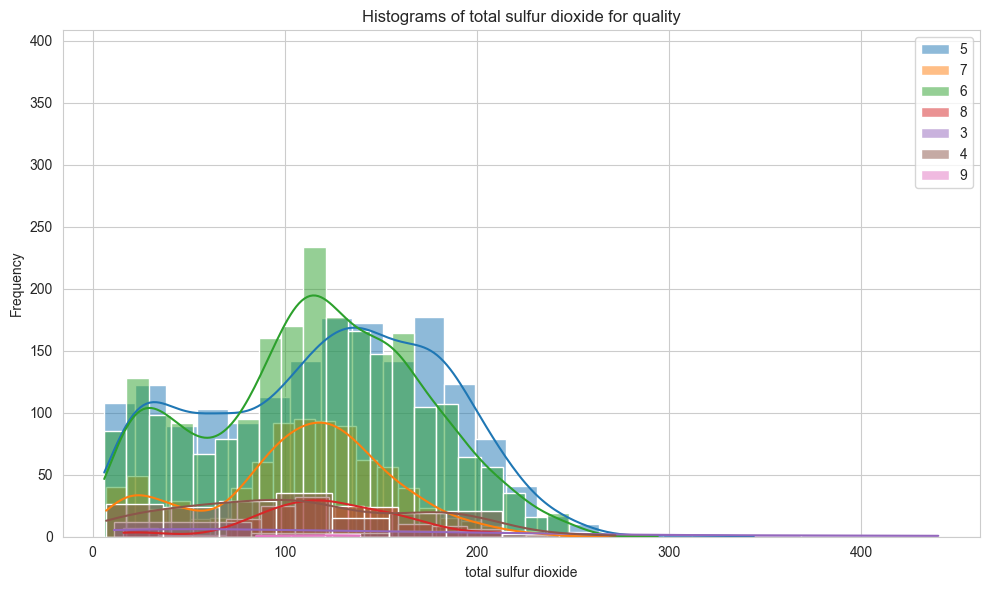

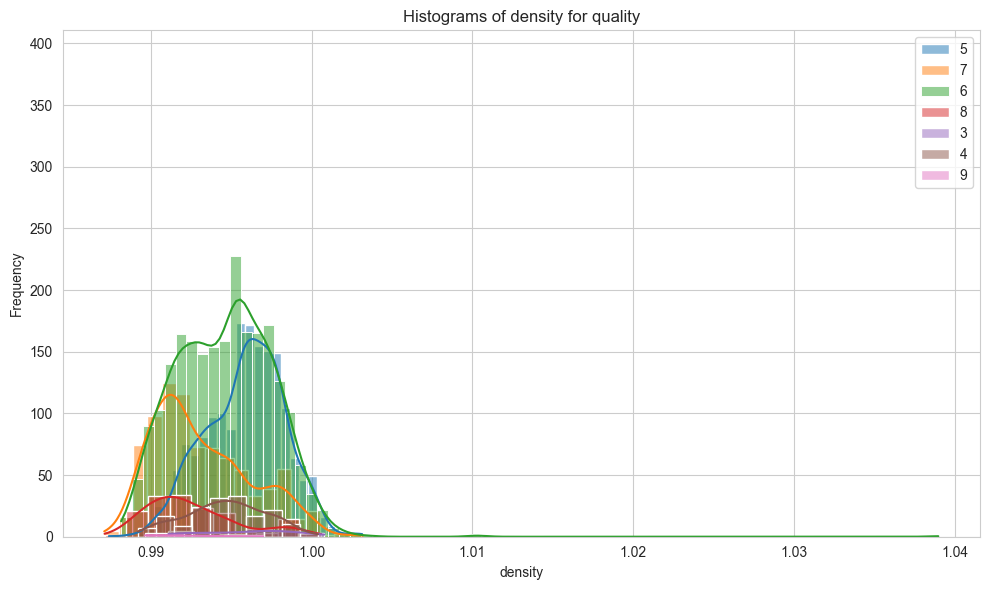

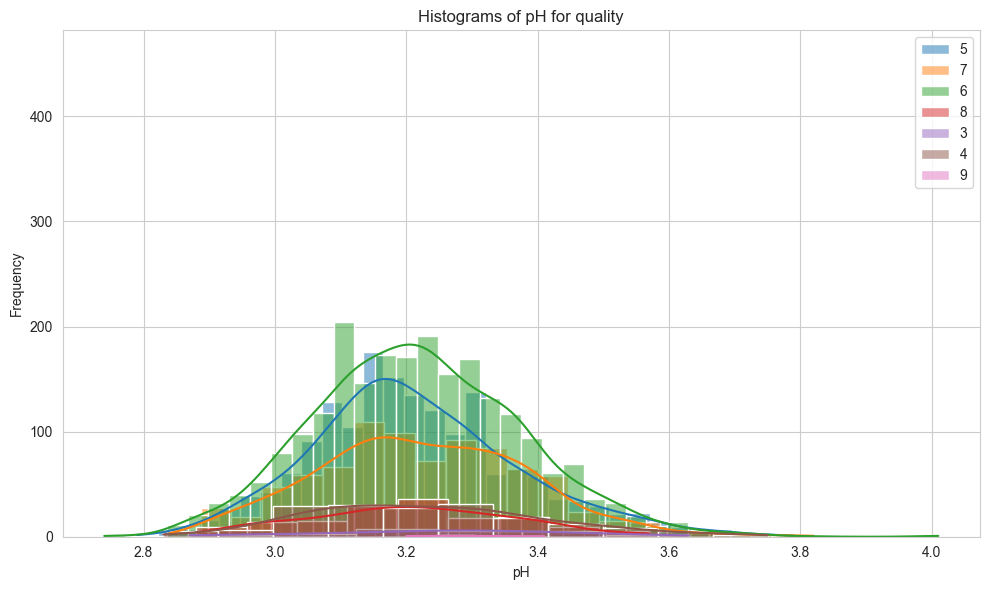

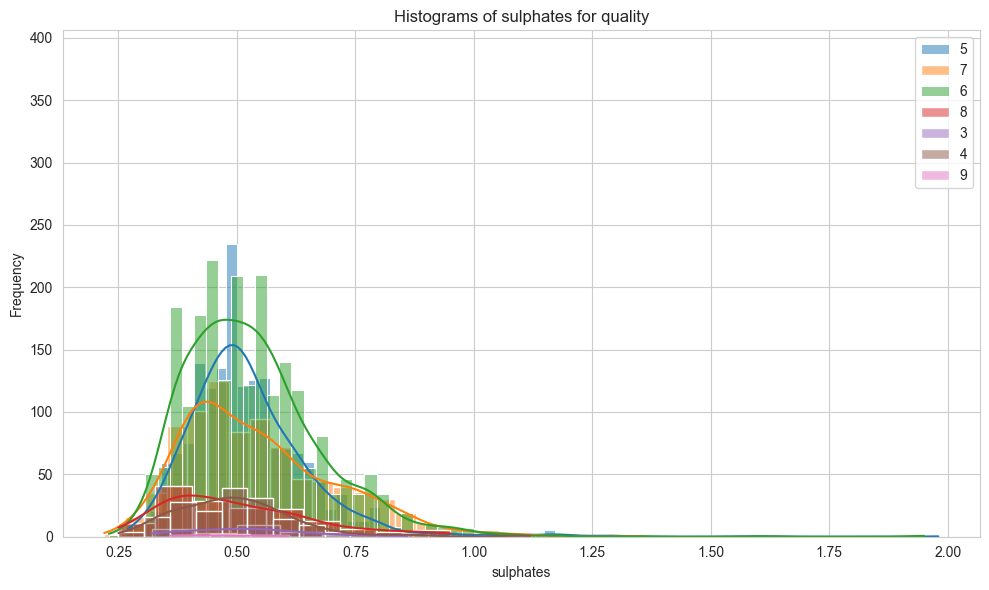

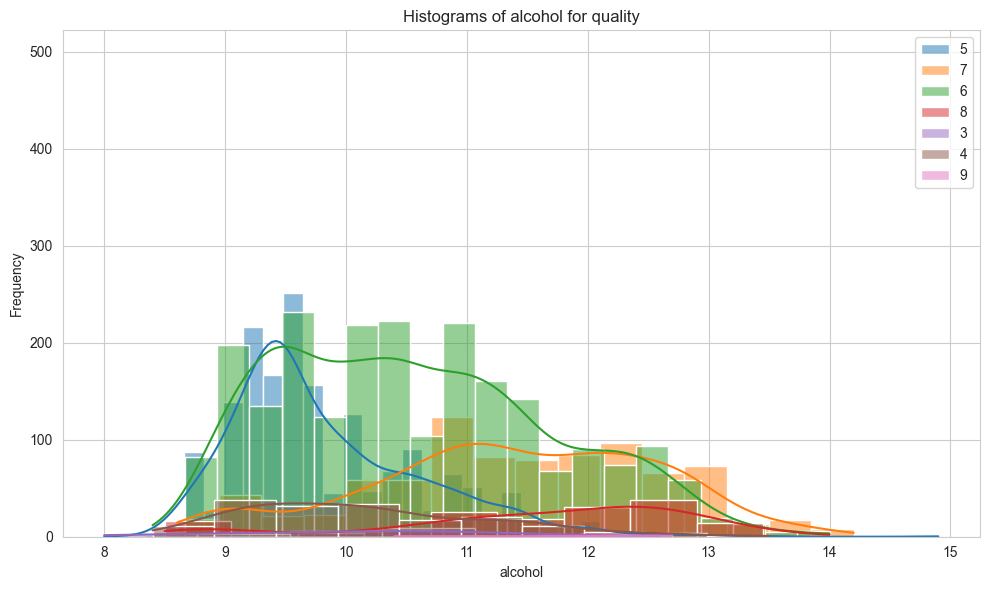

In [13]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target_clf, num_col=col, group_size=train_set[target_clf].nunique())


En vez de valorar a ojo cada histograma, cuantificamos la relación de cada variable
numérica con `quality` usando **información mutua** (`mutual_info_classif`), una medida no
paramétrica que también capta relaciones no lineales -- más objetiva que una inspección
visual variable a variable.

In [14]:
mi_scores = mutual_info_classif(train_set[features_num], train_set[target_clf], random_state=42)
mi_series = pd.Series(mi_scores, index=features_num).sort_values(ascending=False)
mi_series


density                 0.157432
alcohol                 0.146611
chlorides               0.063791
residual sugar          0.060377
total sulfur dioxide    0.059953
citric acid             0.051578
free sulfur dioxide     0.040684
volatile acidity        0.031185
fixed acidity           0.023668
sulphates               0.016333
pH                      0.010254
dtype: float64

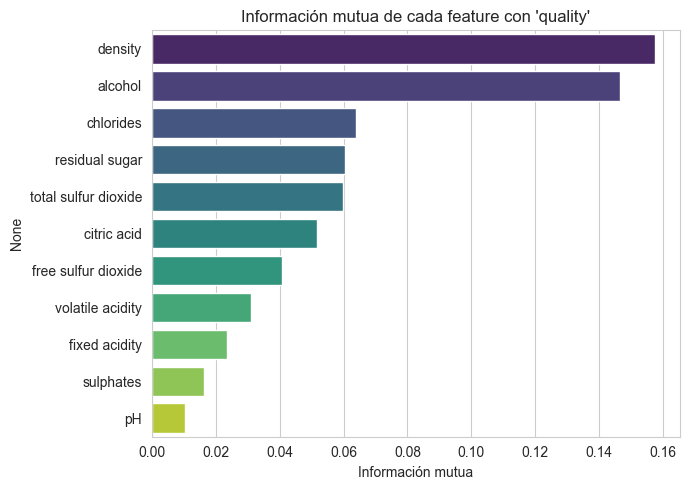

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette="viridis", legend=False)
plt.title("Información mutua de cada feature con 'quality'")
plt.xlabel("Información mutua")
plt.tight_layout()
plt.show()


In [16]:
umbral_mi = mi_series.median()
features_clf_reducido = mi_series[mi_series >= umbral_mi].index.to_list()
features_clf_resto = [c for c in features_num if c not in features_clf_reducido]

print("Reducido (>= mediana de información mutua):", features_clf_reducido)
print("Resto:", features_clf_resto)


Reducido (>= mediana de información mutua): ['density', 'alcohol', 'chlorides', 'residual sugar', 'total sulfur dioxide', 'citric acid']
Resto: ['fixed acidity', 'volatile acidity', 'free sulfur dioxide', 'pH', 'sulphates']


Nos quedamos con dos conjuntos de features para comparar más adelante: uno **reducido**
(las que superan la mediana de información mutua, más `class`) y uno con **todas** las
disponibles.

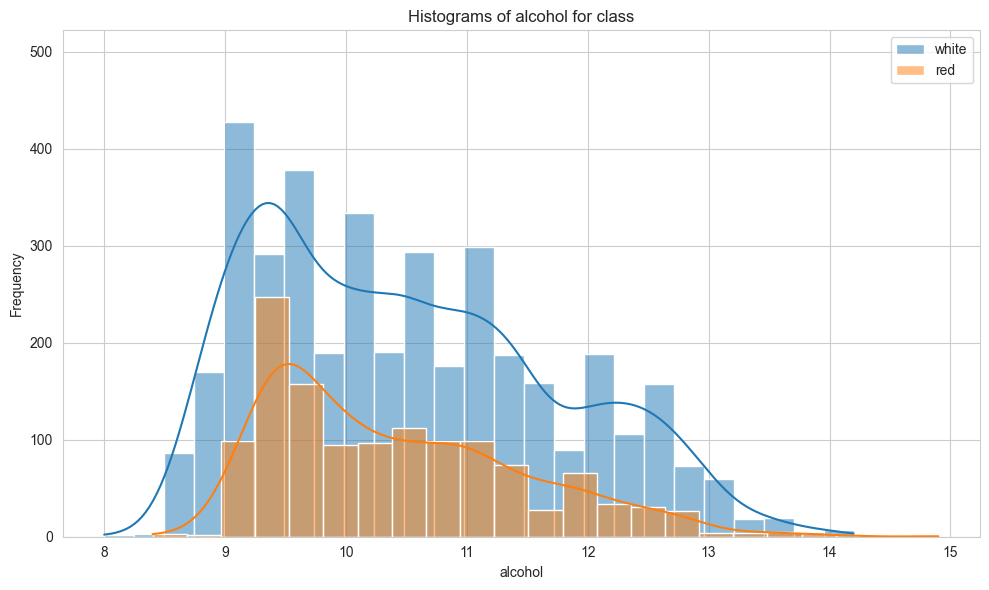

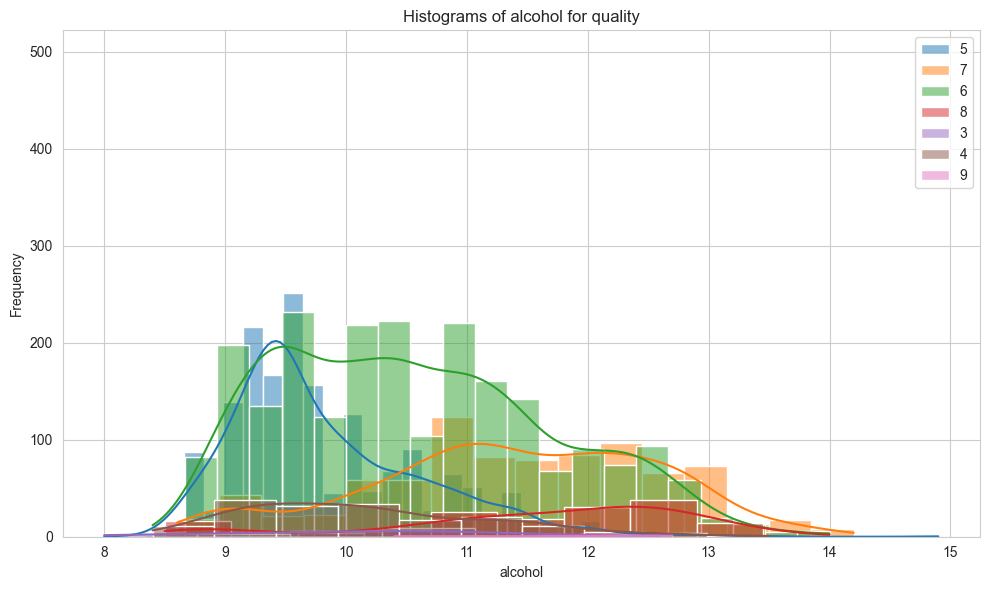

In [17]:
for col in ["class", target_clf]:
    bt.plot_grouped_histograms(train_set, cat_col=col, num_col=target_reg, group_size=train_set[col].nunique())


Tanto `class` como `quality` muestran relación visible con `alcohol` (los tintos parecen
tener un mínimo de alcohol algo mayor, y a más `quality` tiende a haber más alcohol). Las
mantenemos como candidatas y dejamos que los propios modelos terminen de decidir su peso.

**Punto a vigilar**: incluir `quality` como feature de `alcohol` es, en principio,
cuestionable desde el punto de vista de negocio -- la puntuación de los catadores incorpora,
entre otras cosas, su percepción del equilibrio alcohólico del vino, y en un escenario real
esa puntuación solo existe una vez el vino está terminado y catado. Más adelante
comprobaremos **empíricamente** cuánto pesa realmente esta variable en el modelo final, en
vez de asumir sin más que es un problema.

In [18]:
features_cat_reg = ["class", target_clf]
features_num_sin_alcohol = [c for c in features_num if c != target_reg]

corr_alcohol = train_set[features_num_sin_alcohol + [target_reg]].corr()[target_reg].drop(target_reg)
corr_alcohol_abs = corr_alcohol.abs().sort_values(ascending=False)
corr_alcohol_abs


density                 0.683073
residual sugar          0.361373
total sulfur dioxide    0.265385
chlorides               0.260342
free sulfur dioxide     0.175778
pH                      0.113848
fixed acidity           0.085195
volatile acidity        0.043211
sulphates               0.005453
citric acid             0.004981
Name: alcohol, dtype: float64

In [19]:
umbral_corr = 0.08
features_reg_reducido = corr_alcohol_abs[corr_alcohol_abs > umbral_corr].index.to_list()
features_reg_resto = [c for c in features_num if c not in features_reg_reducido and c != target_reg]

print("Reducido (|corr| > 0.08):", features_reg_reducido)
print("Resto:", features_reg_resto)


Reducido (|corr| > 0.08): ['density', 'residual sugar', 'total sulfur dioxide', 'chlorides', 'free sulfur dioxide', 'pH', 'fixed acidity']
Resto: ['volatile acidity', 'citric acid', 'sulphates']


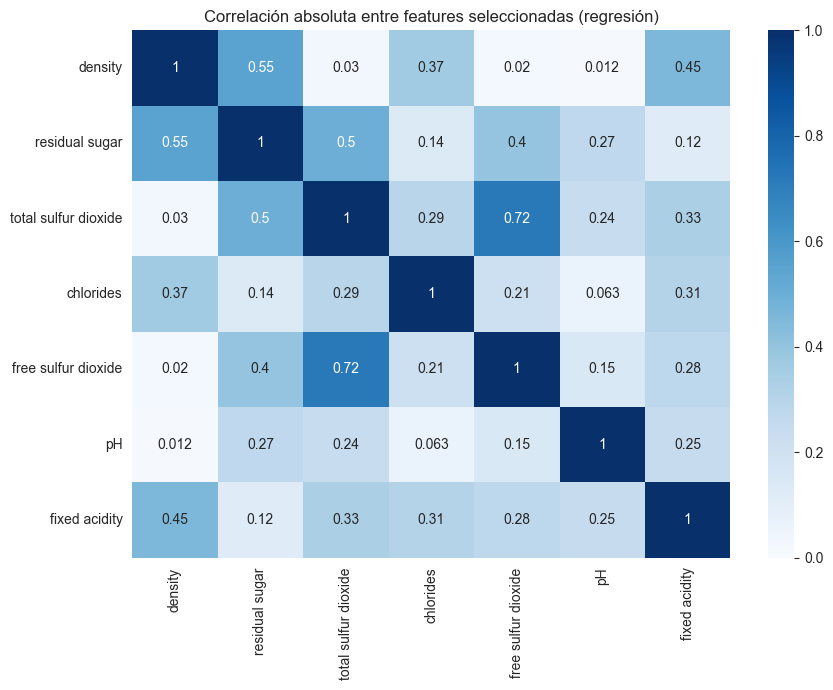

In [20]:
plt.figure(figsize=(9, 7))
sns.heatmap(train_set[features_reg_reducido].corr().abs(), annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlación absoluta entre features seleccionadas (regresión)")
plt.tight_layout()
plt.show()


`free sulfur dioxide` y `total sulfur dioxide` están, como cabía esperar, muy
correlacionadas entre sí (una es subconjunto de la otra). Descartamos `free sulfur dioxide`
del conjunto reducido -- es la que menos correla directamente con `alcohol` de las dos.

In [21]:
features_reg_reducido.remove("free sulfur dioxide")
features_reg_resto.append("free sulfur dioxide")

print("Reducido final:", features_reg_reducido)
print("Resto:", features_reg_resto)


Reducido final: ['density', 'residual sugar', 'total sulfur dioxide', 'chlorides', 'pH', 'fixed acidity']
Resto: ['volatile acidity', 'citric acid', 'sulphates', 'free sulfur dioxide']


**Tratamiento de features**

Necesitamos escalar (usaremos KNN) y codificar `class`.

In [22]:
train_set["class"] = (train_set["class"] == "white").astype(int)  # white -> 1, red -> 0
test_set["class"] = (test_set["class"] == "white").astype(int)


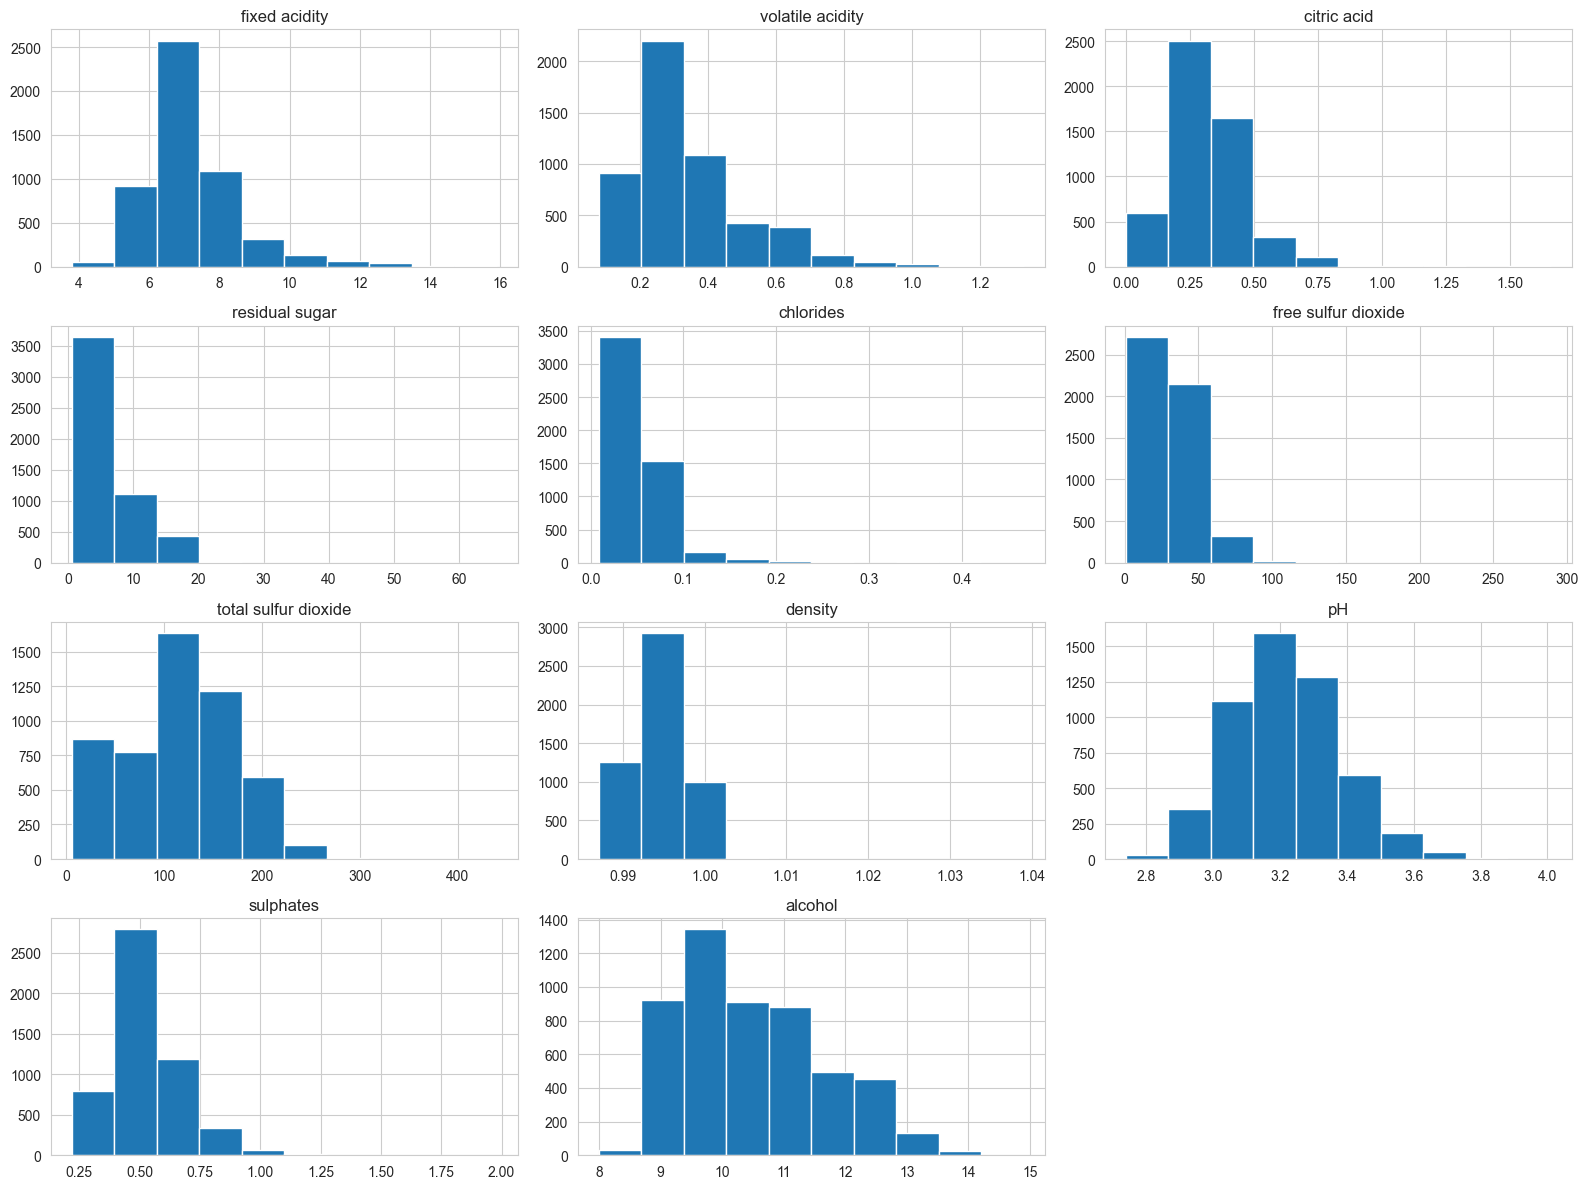

In [23]:
train_set[features_num].hist(figsize=(16, 12))
plt.tight_layout()
plt.show()


Varias columnas están sesgadas hacia la derecha. Generamos una versión transformada +
escalada (para KNN y regresión logística/lineal) y conservamos la versión original (para los
modelos de árboles, que no la necesitan).

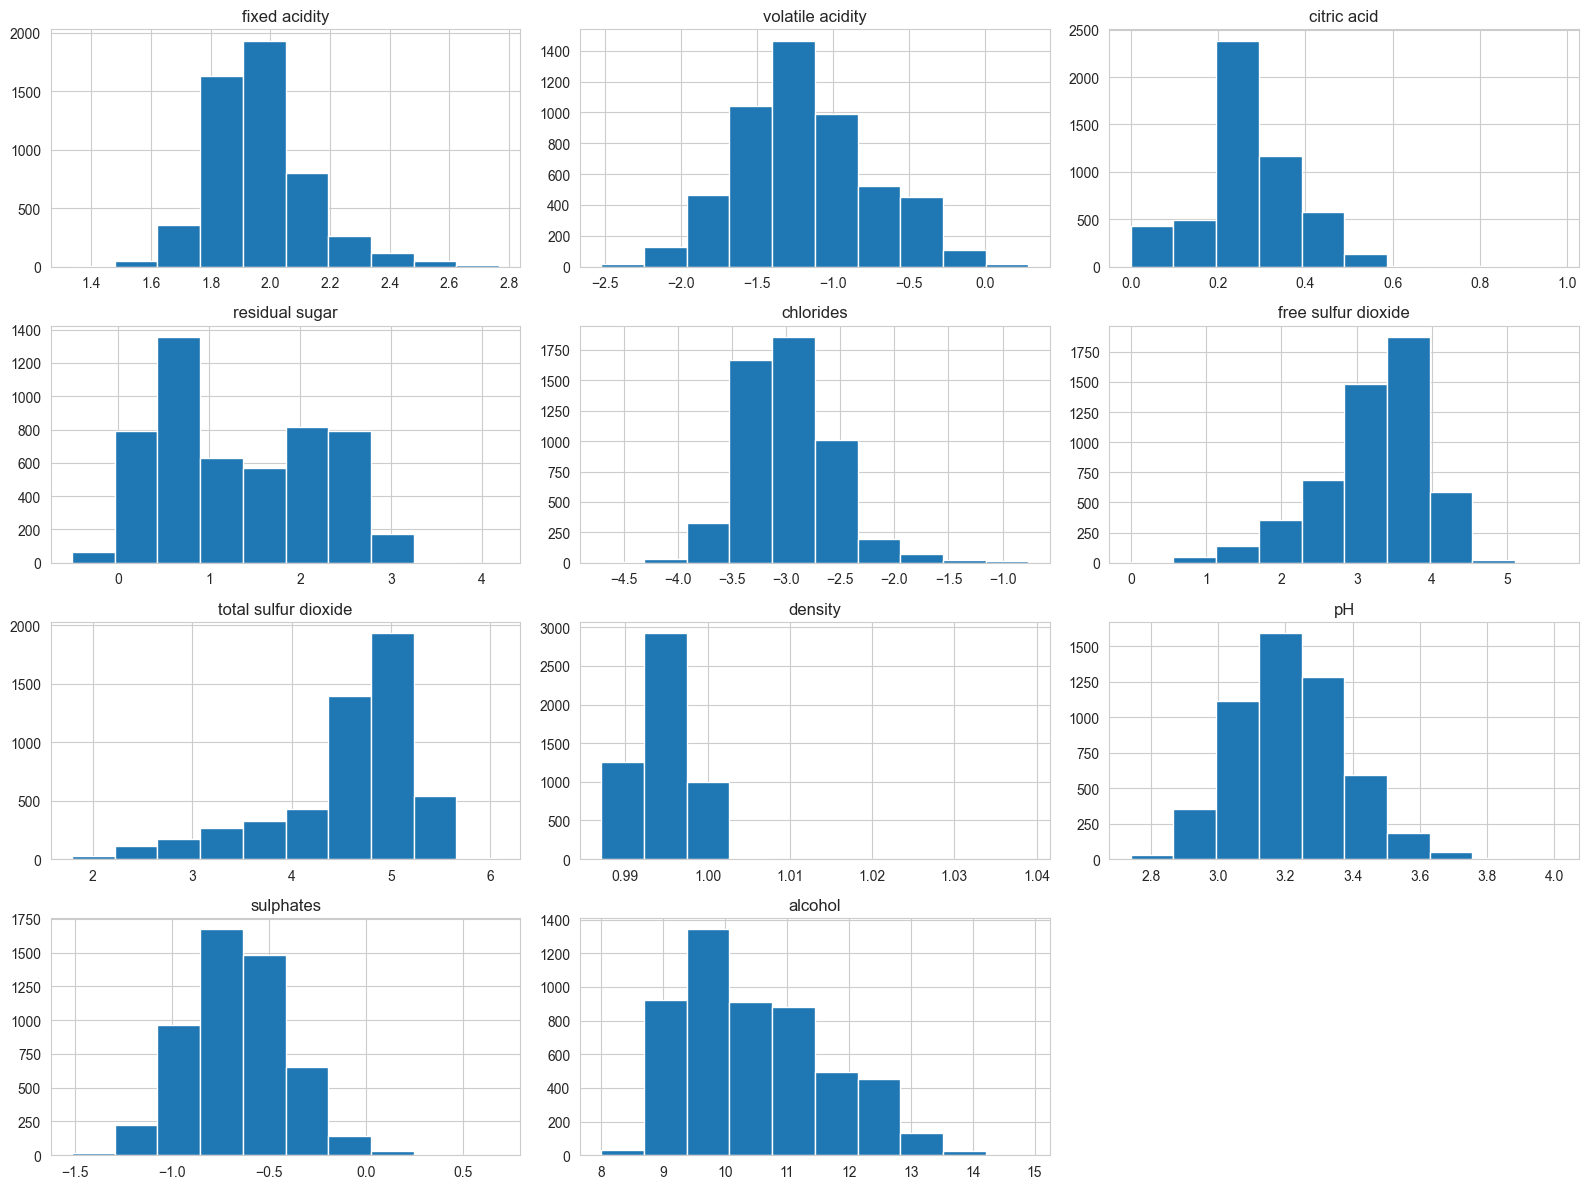

In [24]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

columnas_a_transformar = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "sulphates",
]

for col in columnas_a_transformar:
    desplazamiento = 0
    minimo = train_set_scaled[col].min()
    if minimo <= 0:
        desplazamiento = abs(minimo) + 1
    train_set_scaled[col] = np.log(train_set_scaled[col] + desplazamiento)
    test_set_scaled[col] = np.log(test_set_scaled[col] + desplazamiento)

train_set_scaled[features_num].hist(figsize=(16, 12))
plt.tight_layout()
plt.show()


In [25]:
scaler = StandardScaler()
columnas_a_escalar = [c for c in features_num if c != target_reg]  # alcohol se escala aparte por ser target de regresión

train_set_scaled[columnas_a_escalar] = scaler.fit_transform(train_set_scaled[columnas_a_escalar])
test_set_scaled[columnas_a_escalar] = scaler.transform(test_set_scaled[columnas_a_escalar])

train_set_scaled[columnas_a_escalar].describe().T[["mean", "std"]]


,mean,std
fixed acidity,1.830362e-15,1.000096
volatile acidity,3.623125e-16,1.000096
citric acid,-2.597713e-16,1.000096
residual sugar,1.435578e-16,1.000096
chlorides,-8.008474e-16,1.000096
free sulfur dioxide,-7.902515e-16,1.000096
total sulfur dioxide,-1.852579e-16,1.000096
density,-6.153844e-15,1.000096
pH,1.855314e-15,1.000096
sulphates,1.681677e-16,1.000096


In [26]:
scaler = StandardScaler()
columnas_a_escalar = [c for c in features_num if c != target_reg]  # alcohol se escala aparte por ser target de regresión

train_set_scaled[columnas_a_escalar] = scaler.fit_transform(train_set_scaled[columnas_a_escalar])
test_set_scaled[columnas_a_escalar] = scaler.transform(test_set_scaled[columnas_a_escalar])

train_set_scaled[columnas_a_escalar].describe().T[["mean", "std"]]


,mean,std
fixed acidity,2.700254e-17,1.000096
volatile acidity,-2.939517e-17,1.000096
citric acid,-1.093774e-17,1.000096
residual sugar,-1.709021e-17,1.000096
chlorides,8.886911e-18,1.000096
free sulfur dioxide,2.392630e-17,1.000096
total sulfur dioxide,9.570520e-18,1.000096
density,5.468868e-18,1.000096
pH,3.144599e-17,1.000096
sulphates,-1.640661e-17,1.000096


In [27]:
scaler = StandardScaler()
columnas_a_escalar = [c for c in features_num if c != target_reg]  # alcohol se escala aparte por ser target de regresión

train_set_scaled[columnas_a_escalar] = scaler.fit_transform(train_set_scaled[columnas_a_escalar])
test_set_scaled[columnas_a_escalar] = scaler.transform(test_set_scaled[columnas_a_escalar])

train_set_scaled[columnas_a_escalar].describe().T[["mean", "std"]]


,mean,std
fixed acidity,2.392630e-17,1.000096
volatile acidity,-1.367217e-17,1.000096
citric acid,-9.570520e-18,1.000096
residual sugar,-1.572300e-17,1.000096
chlorides,1.401398e-17,1.000096
free sulfur dioxide,2.119187e-17,1.000096
total sulfur dioxide,7.519694e-18,1.000096
density,5.468868e-18,1.000096
pH,1.367217e-17,1.000096
sulphates,-1.503939e-17,1.000096


**Construimos los distintos juegos de X, y**

In [28]:
y_train_clf = train_set[target_clf]
y_test_clf = test_set[target_clf]

y_train_reg = train_set[target_reg]
y_test_reg = test_set[target_reg]

X_train_clf = {
    "reducido": train_set_scaled[["class"] + features_clf_reducido],
    "todas": train_set_scaled[["class"] + features_clf_reducido + features_clf_resto],
}
X_test_clf = {
    "reducido": test_set_scaled[["class"] + features_clf_reducido],
    "todas": test_set_scaled[["class"] + features_clf_reducido + features_clf_resto],
}

X_train_reg = {
    "reducido": train_set_scaled[features_cat_reg + features_reg_reducido],
    "todas": train_set_scaled[features_cat_reg + features_reg_reducido + features_reg_resto],
}
X_test_reg = {
    "reducido": test_set_scaled[features_cat_reg + features_reg_reducido],
    "todas": test_set_scaled[features_cat_reg + features_reg_reducido + features_reg_resto],
}

{k: v.shape for k, v in X_train_clf.items()}


{'reducido': (5197, 7), 'todas': (5197, 12)}

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [29]:
def modelos_regresion():
    return {
        "LinearRegression": LinearRegression(),
        "DecisionTree": DecisionTreeRegressor(max_depth=8, random_state=42),
        "RandomForest": RandomForestRegressor(max_depth=10, random_state=42),
        "HistGradientBoosting": HistGradientBoostingRegressor(max_depth=10, random_state=42),
    }


for feature_set, X_tr in X_train_reg.items():
    print(f"--- feature set: {feature_set} ---")
    for nombre, modelo in modelos_regresion().items():
        mape = -cross_val_score(modelo, X_tr, y_train_reg, cv=3, scoring="neg_mean_absolute_percentage_error").mean()
        print(f"  {nombre:22s}: MAPE = {mape:.4f}")


--- feature set: reducido ---
  LinearRegression      : MAPE = 0.0414
  DecisionTree          : MAPE = 0.0406
  RandomForest          : MAPE = 0.0314
  HistGradientBoosting  : MAPE = 0.0290
--- feature set: todas ---
  LinearRegression      : MAPE = 0.0403
  DecisionTree          : MAPE = 0.0408
  RandomForest          : MAPE = 0.0307
  HistGradientBoosting  : MAPE = 0.0272


### Optimización de hiperparámetros -- regresión

In [30]:
param_dist_reg = {
    "max_iter": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [5, 10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_reg_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_reg,
    n_iter=12,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    random_state=42,
    n_jobs=1,
)
hgb_reg_search.fit(X_train_reg["todas"], y_train_reg)

print("Mejores hiperparámetros:", hgb_reg_search.best_params_)
print(f"MAPE CV-3: {-hgb_reg_search.best_score_:.4f}")


Mejores hiperparámetros: {'min_samples_leaf': 5, 'max_iter': 200, 'max_depth': None, 'learning_rate': 0.2, 'l2_regularization': 0.1}
MAPE CV-3: 0.0248


In [33]:
param_dist_reg = {
    "max_iter": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [5, 10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_reg_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_reg,
    n_iter=12,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    random_state=42,
    n_jobs=1,
)
hgb_reg_search.fit(X_train_reg["todas"], y_train_reg)

print("Mejores hiperparámetros:", hgb_reg_search.best_params_)
print(f"MAPE CV-3: {-hgb_reg_search.best_score_:.4f}")


Mejores hiperparámetros: {'min_samples_leaf': 5, 'max_iter': 200, 'max_depth': None, 'learning_rate': 0.2, 'l2_regularization': 0.1}
MAPE CV-3: 0.0248


In [35]:
y_pred_reg = hgb_reg_search.best_estimator_.predict(X_test_reg["todas"])
print("MAPE en test:", mean_absolute_percentage_error(y_test_reg, y_pred_reg))

MAPE en test: 0.023341815132597487


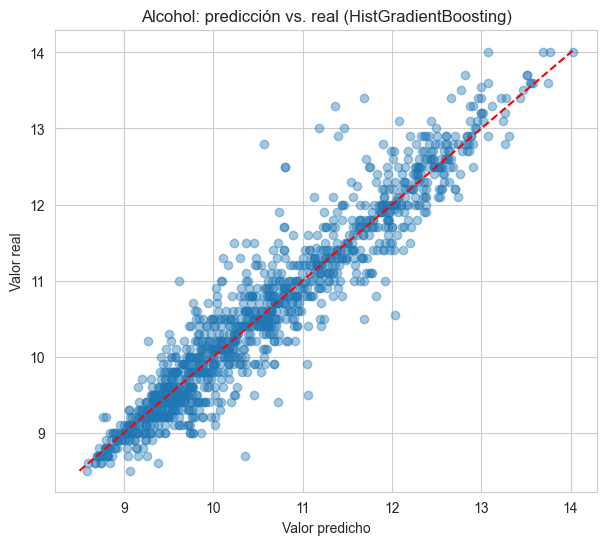

In [36]:
plot_predicciones_vs_reales(y_test_reg, y_pred_reg, titulo="Alcohol: predicción vs. real (HistGradientBoosting)")


In [37]:
importancia_perm_reg = permutation_importance(
    hgb_reg_search.best_estimator_, X_test_reg["todas"], y_test_reg,
    n_repeats=10, random_state=42, scoring="neg_mean_absolute_percentage_error", n_jobs=1,
)

df_importancia_reg = pd.DataFrame({
    "feature": X_test_reg["todas"].columns,
    "importancia_media": importancia_perm_reg.importances_mean,
}).sort_values("importancia_media", ascending=False)

df_importancia_reg


,feature,importancia_media
2,density,0.138385
3,residual sugar,0.045931
7,fixed acidity,0.020927
6,pH,0.015727
0,class,0.009033
4,total sulfur dioxide,0.006832
10,sulphates,0.006257
8,volatile acidity,0.004277
5,chlorides,0.003439
9,citric acid,0.003342


Comprobación peso  `quality` 

Repetimos la validación cruzada del modelo ganador, pero quitando `quality` de las features

In [38]:
features_sin_quality = [c for c in X_train_reg["todas"].columns if c != target_clf]

mape_con_quality = -cross_val_score(
    HistGradientBoostingRegressor(**{k: v for k, v in hgb_reg_search.best_params_.items()}, random_state=42),
    X_train_reg["todas"], y_train_reg, cv=3, scoring="neg_mean_absolute_percentage_error",
).mean()

mape_sin_quality = -cross_val_score(
    HistGradientBoostingRegressor(**{k: v for k, v in hgb_reg_search.best_params_.items()}, random_state=42),
    X_train_reg["todas"][features_sin_quality], y_train_reg, cv=3, scoring="neg_mean_absolute_percentage_error",
).mean()

print(f"MAPE con 'quality' como feature   : {mape_con_quality:.4f}")
print(f"MAPE sin 'quality' como feature   : {mape_sin_quality:.4f}")


MAPE con 'quality' como feature   : 0.0248
MAPE sin 'quality' como feature   : 0.0246


## Conclusiones

- **Clasificación**: `quality` es un target multiclase muy desbalanceado. El balanceo vía
  `class_weight`/`weights="distance"` mejoró notablemente todos los modelos.
  `HistGradientBoosting` fue el más consistente, y tras optimizar hiperparámetros logra un
  recall medio razonable en la franja central de calidades, con más dificultad en las
  puntuaciones extremas (muy minoritarias).
- **Regresión**: `HistGradientBoosting` también resultó ganador para predecir `alcohol`,
  con errores (MAPE) muy bajos, en torno al 2-3%.
- Planteamos la hipótesis de que incluir `quality` como feature podría estar inflando
  artificialmente ese buen resultado (una posible fuga de información de negocio), pero al
  comprobarlo empíricamente -- tanto con importancia por permutación como retirando la
  variable y reentrenando -- **la hipótesis no se sostuvo**: `quality` apenas influye, y el
  verdadero motivo del buen ajuste son variables fisicoquímicas legítimas como `density`.
  Buen recordatorio de que las sospechas de fuga de información hay que confirmarlas con
  datos, no darlas por hecho.
- En ambos problemas, la importancia por permutación coincidió razonablemente con la
  intuición obtenida en el mini-EDA inicial.